## 1. Setup & Load


In [71]:
import os
import json
import time
import warnings
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

warnings.filterwarnings("ignore")


In [72]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150


In [73]:
df = pd.read_csv("../data/Airbnb_Data.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Loaded: 74,111 rows × 29 columns


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


## 2. Data Cleaning


In [74]:
drop_cols = ["id", "thumbnail_url", "name", "description"]
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Dropped {len(drop_cols)} columns: {drop_cols}")


Dropped 4 columns: ['id', 'thumbnail_url', 'name', 'description']


### Parse host_response_rate


In [75]:
df["host_response_rate"] = (
    df["host_response_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)
print(f"host_response_rate — nulls: {df['host_response_rate'].isnull().sum()}, "
      f"median: {df['host_response_rate'].median():.0f}")


host_response_rate — nulls: 18299, median: 100


### Map boolean columns


In [76]:
bool_cols = ["cleaning_fee", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]
for col in bool_cols:
    df[col] = df[col].map({"t": 1, "f": 0, True: 1, False: 0})
print("Mapped boolean columns to 0/1")
df[bool_cols].head()


Mapped boolean columns to 0/1


,cleaning_fee,host_has_profile_pic,host_identity_verified,instant_bookable
0,1,1.0,1.0,0
1,1,1.0,0.0,1
2,1,1.0,1.0,1
3,1,1.0,1.0,0
4,1,1.0,1.0,1


### Convert date columns


In [77]:
date_cols = ["host_since", "first_review", "last_review"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")


In [78]:
REFERENCE_DATE = pd.Timestamp("2018-12-31")
print(f"Reference date: {REFERENCE_DATE.date()}")


Reference date: 2018-12-31


In [79]:
df["host_tenure_days"] = (REFERENCE_DATE - df["host_since"]).dt.days
df.drop(columns=["host_since"], inplace=True)


In [80]:
df["days_since_first_review"] = (REFERENCE_DATE - df["first_review"]).dt.days
df.drop(columns=["first_review"], inplace=True)


In [81]:
df["days_since_last_review"] = (REFERENCE_DATE - df["last_review"]).dt.days
df.drop(columns=["last_review"], inplace=True)


### Fill nulls


In [82]:
num_fill_cols = ["bathrooms", "bedrooms", "beds", "review_scores_rating", "host_response_rate"]
for col in num_fill_cols:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col}: filled with median {median_val:.2f}")


  bathrooms: filled with median 1.00
  bedrooms: filled with median 1.00
  beds: filled with median 1.00
  review_scores_rating: filled with median 96.00
  host_response_rate: filled with median 100.00


In [83]:
cat_fill_cols = ["neighbourhood", "zipcode"]
for col in cat_fill_cols:
    if col in df.columns and df[col].isnull().any():
        n_nulls = df[col].isnull().sum()
        df[col].fillna("Unknown", inplace=True)
        print(f"  {col}: filled {n_nulls} nulls with 'Unknown'")


  neighbourhood: filled 6872 nulls with 'Unknown'
  zipcode: filled 966 nulls with 'Unknown'


In [84]:
before = len(df)
df.dropna(inplace=True)
df = df[df["log_price"].notnull()]
print(f"Dropped {before - len(df)} rows with remaining nulls")
print(f"After cleaning: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dropped 31336 rows with remaining nulls
After cleaning: 42,775 rows × 25 columns


In [85]:
df.dtypes.value_counts()


float64    13
str         8
int64       4
Name: count, dtype: int64

## 3. Feature Engineering


### Parse amenities


In [86]:
def parse_amenities(raw):
    if not isinstance(raw, str):
        return []
    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, (list, set)):
            return [str(a).strip().strip('"').strip("'") for a in parsed]
    except Exception:
        pass
    return [a.strip().strip('"').strip("'").strip("{").strip("}") for a in raw.split(",")]

df["_amenities_list"] = df["amenities"].apply(parse_amenities)


In [87]:
df["amenities_count"] = df["_amenities_list"].apply(len)
print(f"amenities_count — min: {df['amenities_count'].min()}, "
      f"max: {df['amenities_count'].max()}, mean: {df['amenities_count'].mean():.1f}")


amenities_count — min: 1, max: 77, mean: 19.2


### Amenity binary flags


In [88]:
high_value_amenities = [
    "Wireless Internet", "Air conditioning", "Kitchen", "Heating", "Washer", "Dryer",
    "Free parking on premises", "Gym", "Pool", "Hot tub", "TV", "Essentials",
    "Internet", "Cable TV"
]

for amenity in high_value_amenities:
    safe_name = amenity.replace(" ", "_").replace("/", "_").lower()
    df[f"amenity_{safe_name}"] = df["_amenities_list"].apply(
        lambda lst, a=amenity: 1 if a in lst else 0
    )

print(f"Created {len(high_value_amenities)} amenity flag columns")


Created 14 amenity flag columns


In [89]:
df.drop(columns=["amenities", "_amenities_list"], inplace=True)
print("Dropped raw amenities columns")
print(f"Shape: {df.shape}")


Dropped raw amenities columns
Shape: (42775, 39)


## 4. Encoding


In [90]:
onehot_cols = ["city", "room_type", "property_type", "bed_type", "cancellation_policy"]
onehot_cols = [c for c in onehot_cols if c in df.columns]
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True, dummy_na=True)
print(f"One-hot encoded {len(onehot_cols)} columns")
print(f"Shape after one-hot: {df.shape}")


One-hot encoded 5 columns
Shape after one-hot: (42775, 84)


In [91]:
label_cols = ["zipcode", "neighbourhood"]
for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    print(f"Label encoded '{col}' — {len(le.classes_)} classes")


Label encoded 'zipcode' — 659 classes
Label encoded 'neighbourhood' — 590 classes


In [92]:
feature_names = [c for c in df.columns if c != "log_price"]
print(f"Total features: {len(feature_names)}")


Total features: 83


## 5. Train / Val / Test Split


In [93]:
y = df["log_price"]
X = df.drop(columns=["log_price"])

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
val_ratio = 0.15 / (1 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_ratio, random_state=42)

print(f"Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}  |  Test: {X_test.shape[0]:,}")


Train: 29,941  |  Val: 6,417  |  Test: 6,417


In [94]:
print(f"Feature count: {X_train.shape[1]}")


Feature count: 83


## 6. Linear Regression — Baseline


In [95]:
lr = LinearRegression()
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
lr_pred = lr.predict(X_val)
lr_mae = mean_absolute_error(y_val, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))
lr_r2 = r2_score(y_val, lr_pred)
print(f"Linear Regression — MAE: {lr_mae:.4f}  |  RMSE: {lr_rmse:.4f}  |  R²: {lr_r2:.4f}")


Linear Regression — MAE: 0.2895  |  RMSE: 0.3835  |  R²: 0.6777


## 7. Random Forest


In [97]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Training time: {time.time() - t0:.1f}s")


Training time: 4.9s


In [98]:
rf_pred = rf.predict(X_val)
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_r2 = r2_score(y_val, rf_pred)
print(f"Random Forest — MAE: {rf_mae:.4f}  |  RMSE: {rf_rmse:.4f}  |  R²: {rf_r2:.4f}")


Random Forest — MAE: 0.2406  |  RMSE: 0.3273  |  R²: 0.7653


## 8. XGBoost


In [99]:
t0 = time.time()
xgb = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
print(f"Training time: {time.time() - t0:.1f}s")


Training time: 2.6s


In [100]:
xgb_pred = xgb.predict(X_val)
xgb_mae = mean_absolute_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2 = r2_score(y_val, xgb_pred)
print(f"XGBoost — MAE: {xgb_mae:.4f}  |  RMSE: {xgb_rmse:.4f}  |  R²: {xgb_r2:.4f}")


XGBoost — MAE: 0.2312  |  RMSE: 0.3131  |  R²: 0.7852


## 9. LightGBM


In [101]:
t0 = time.time()
lgb = LGBMRegressor(
    n_estimators=500, random_state=42, n_jobs=-1, verbose=-1
)
lgb.fit(X_train, y_train)
print(f"Training time: {time.time() - t0:.1f}s")


Training time: 3.4s


In [102]:
lgb_pred = lgb.predict(X_val)
lgb_mae = mean_absolute_error(y_val, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_pred))
lgb_r2 = r2_score(y_val, lgb_pred)
print(f"LightGBM — MAE: {lgb_mae:.4f}  |  RMSE: {lgb_rmse:.4f}  |  R²: {lgb_r2:.4f}")


LightGBM — MAE: 0.2325  |  RMSE: 0.3157  |  R²: 0.7816


## 10. Model Comparison


In [103]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "LightGBM"],
    "MAE": [lr_mae, rf_mae, xgb_mae, lgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse, lgb_rmse],
    "R²": [lr_r2, rf_r2, xgb_r2, lgb_r2],
})
results = results.sort_values("R²", ascending=False).reset_index(drop=True)
results.round(4)


,Model,MAE,RMSE,R²
0,XGBoost,0.2312,0.3131,0.7852
1,LightGBM,0.2325,0.3157,0.7816
2,Random Forest,0.2406,0.3273,0.7653
3,Linear Regression,0.2895,0.3835,0.6777


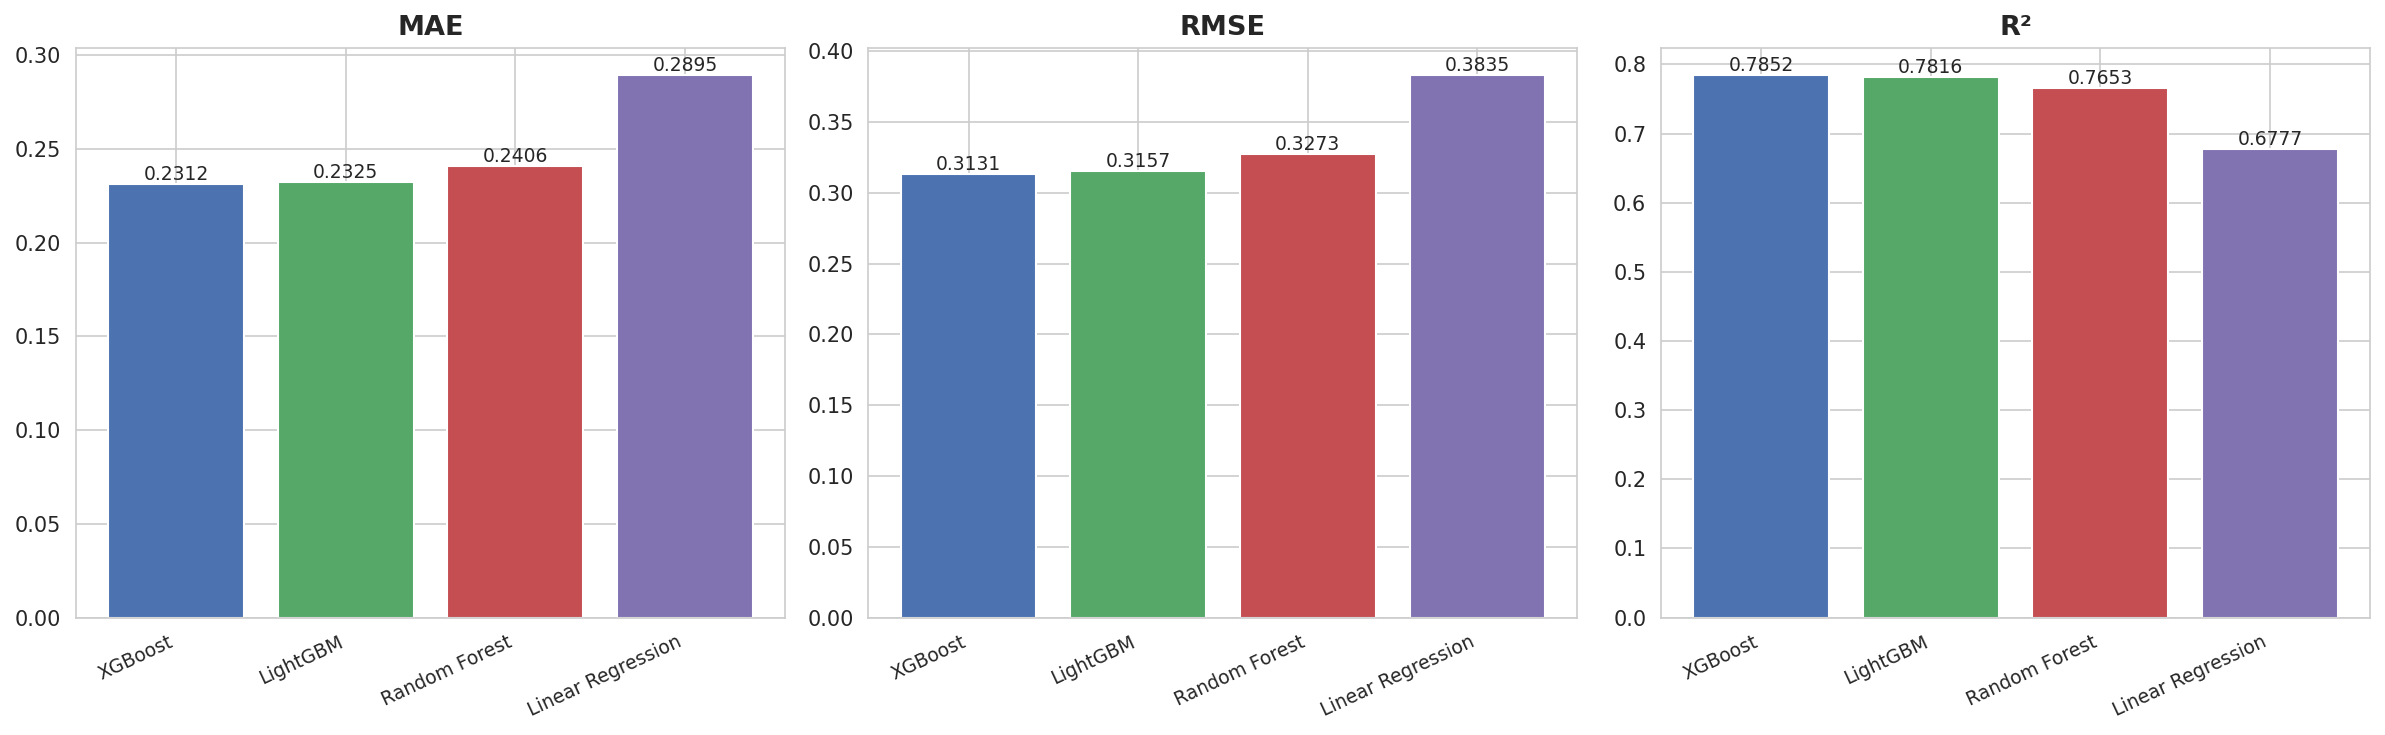

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["MAE", "RMSE", "R²"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for ax, metric in zip(axes, metrics):
    bars = ax.bar(results["Model"], results[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xticks(range(len(results["Model"])))
    ax.set_xticklabels(results["Model"], rotation=25, ha="right", fontsize=9)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f"{height:.4f}",
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning — XGBoost


In [105]:
param_distributions = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2],
}


In [106]:
t0 = time.time()
base_xgb = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)
print(f"Search completed in {time.time() - t0:.1f}s")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Search completed in 131.0s


In [107]:
best_model = search.best_estimator_
print(f"Best CV MAE: {-search.best_score_:.4f}")
print(f"Best params: {json.dumps(search.best_params_, indent=2)}")


Best CV MAE: 0.2292
Best params: {
  "subsample": 0.6,
  "reg_lambda": 1.5,
  "reg_alpha": 1,
  "n_estimators": 1000,
  "min_child_weight": 1,
  "max_depth": 8,
  "learning_rate": 0.05,
  "gamma": 0.1,
  "colsample_bytree": 0.6
}


## 12. Best Model Evaluation


### Test-set metrics


In [108]:
best_pred = best_model.predict(X_test)
best_mae = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)
print(f"Test — MAE: {best_mae:.4f}  |  RMSE: {best_rmse:.4f}  |  R²: {best_r2:.4f}")


Test — MAE: 0.2336  |  RMSE: 0.3194  |  R²: 0.7687


### Feature importance


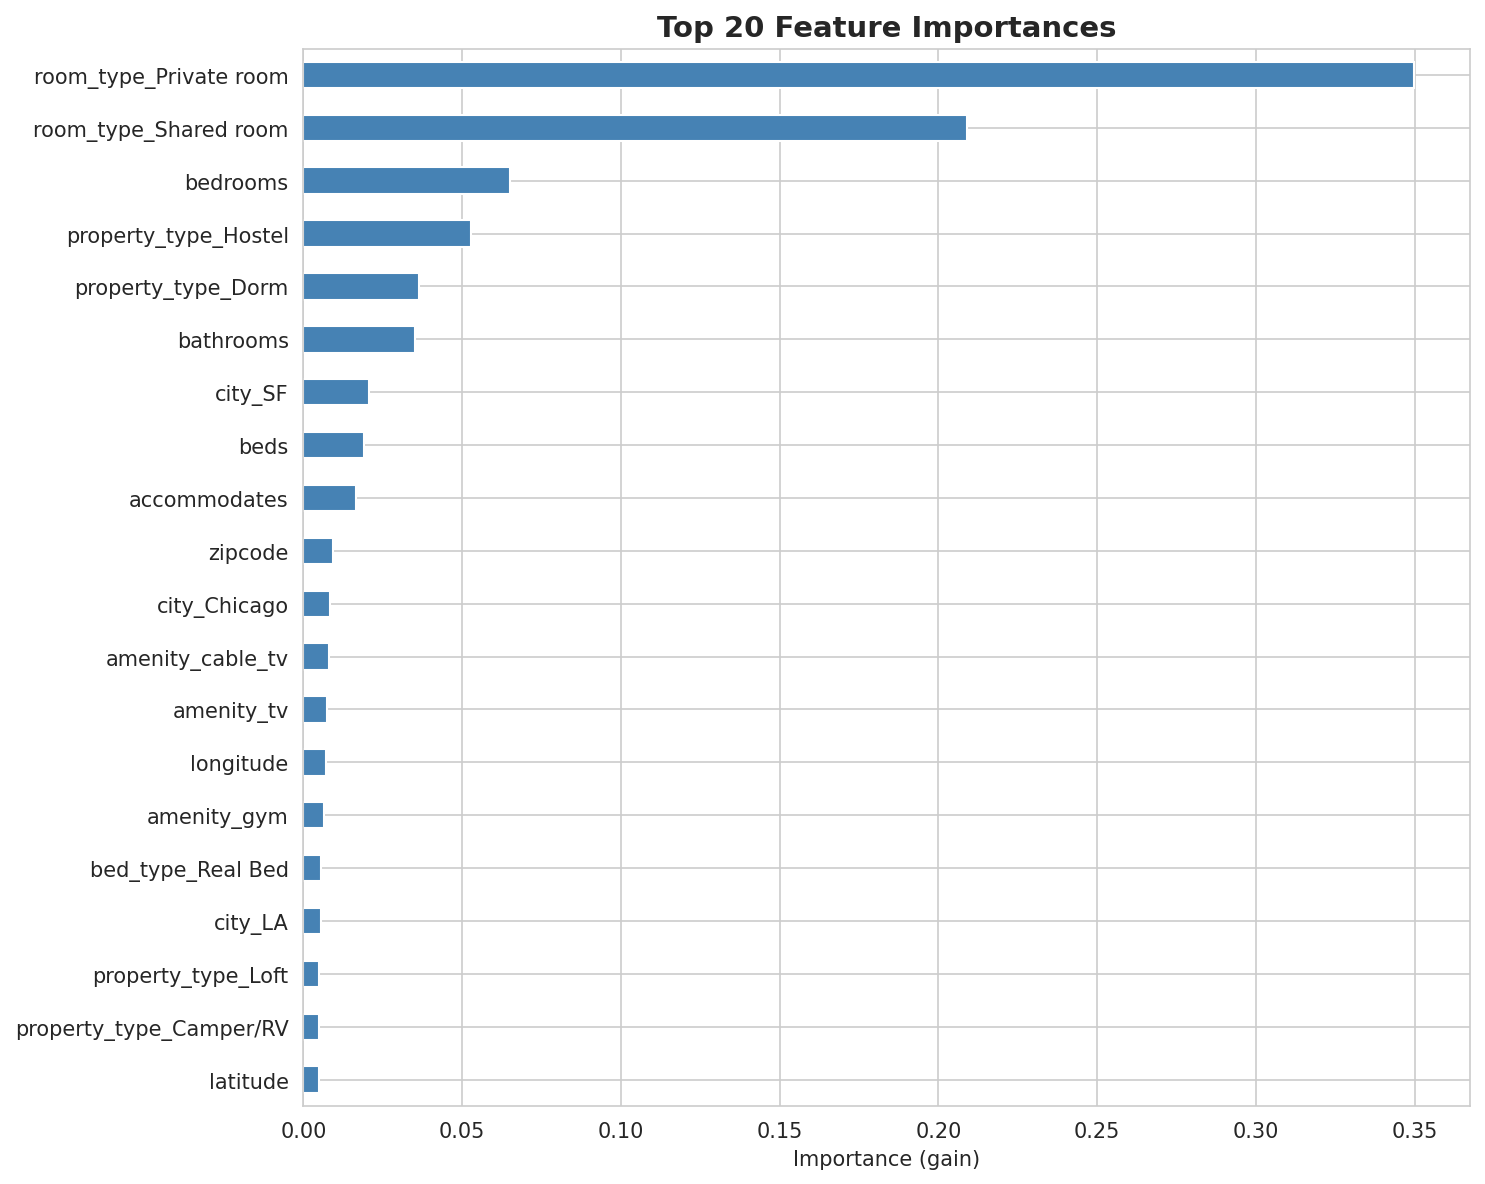

In [109]:
importances = pd.Series(best_model.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Feature Importances", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()


### Predictions scatter


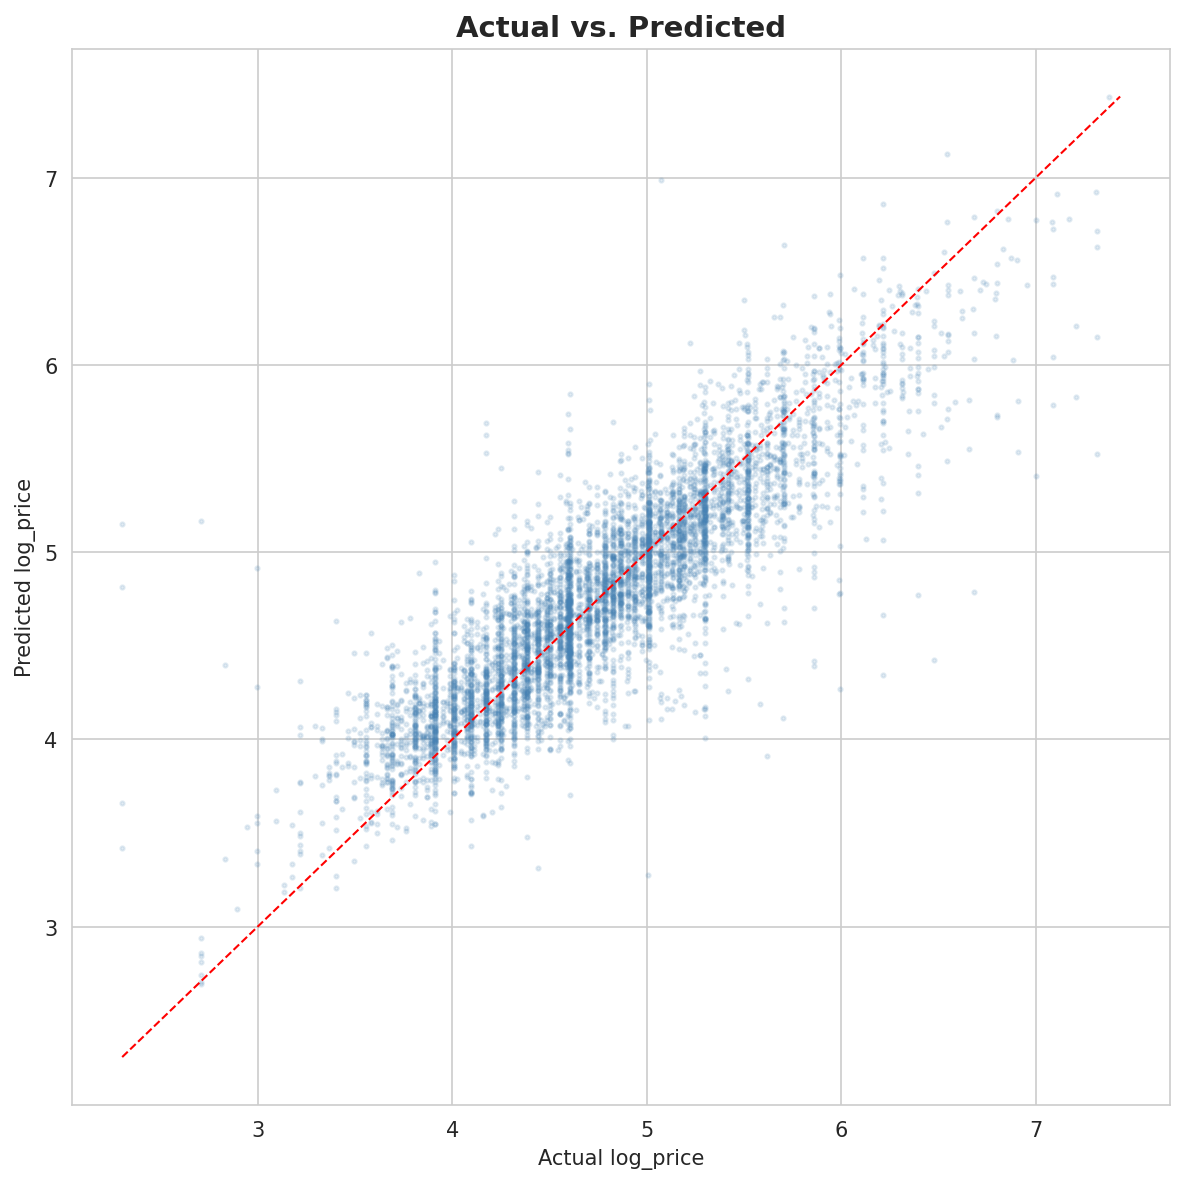

In [110]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, best_pred, alpha=0.15, s=4, color="steelblue")
lo = min(y_test.min(), best_pred.min())
hi = max(y_test.max(), best_pred.max())
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
ax.set_xlabel("Actual log_price")
ax.set_ylabel("Predicted log_price")
ax.set_title("Actual vs. Predicted", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Residual distribution


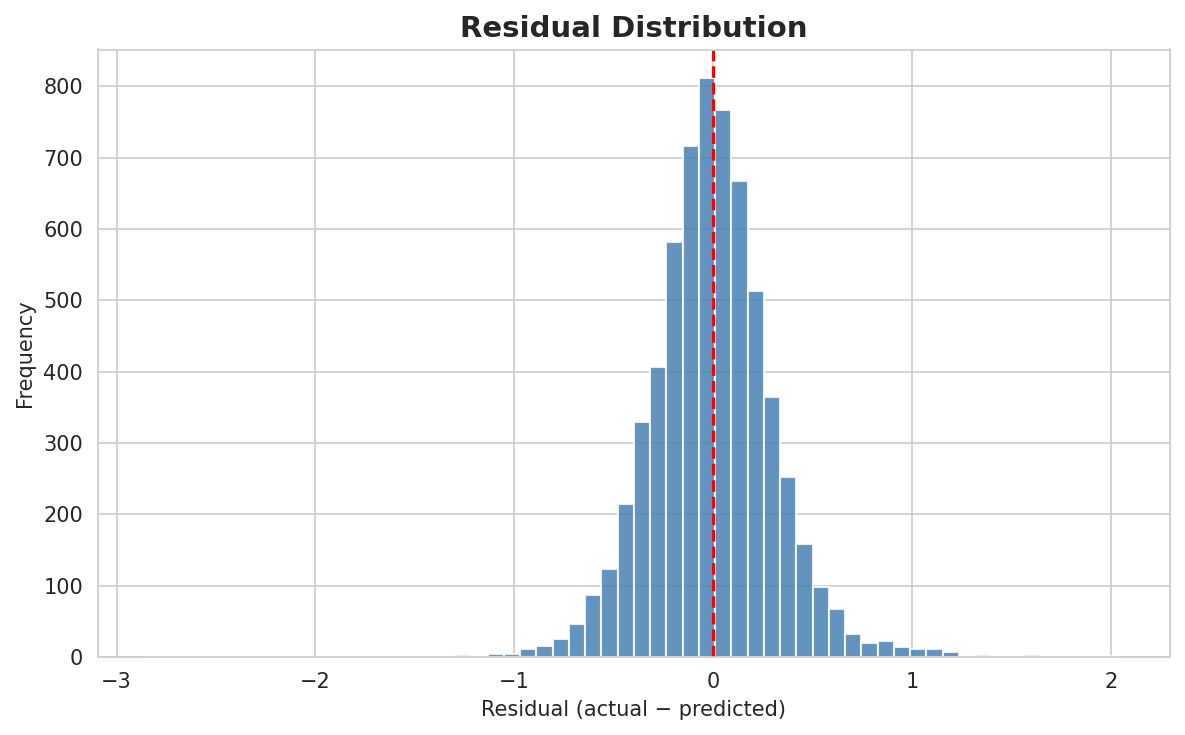

In [111]:
residuals = y_test.values - best_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (actual − predicted)")
ax.set_ylabel("Frequency")
ax.set_title("Residual Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 13. Save Artifacts


In [112]:
os.makedirs("../artifacts", exist_ok=True)
joblib.dump(best_model, "../artifacts/xgboost_best.joblib")
print("Model saved to ../artifacts/xgboost_best.joblib")


Model saved to ../artifacts/xgboost_best.joblib


In [113]:
with open("../artifacts/feature_names.json", "w") as f:
    json.dump({"feature_names": feature_names, "timestamp": time.strftime("%Y-%m-%dT%H:%M:%SZ")}, f, indent=2)
print(f"Saved {len(feature_names)} feature names")


Saved 83 feature names


In [114]:
perf_df = pd.DataFrame([{
    "mae": round(best_mae, 4),
    "rmse": round(best_rmse, 4),
    "r2": round(best_r2, 4),
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%SZ"),
}])
perf_df.to_csv("../artifacts/model_performance.csv", index=False)
perf_df


,mae,rmse,r2,timestamp
0,0.2336,0.3194,0.7687,2026-05-11T12:53:26Z


In [115]:
print("Done! Training pipeline complete.")
print(f"Final model: XGBoost (tuned) — R² = {best_r2:.4f}")


Done! Training pipeline complete.
Final model: XGBoost (tuned) — R² = 0.7687
